<a href="https://colab.research.google.com/github/diabateyoussouf/Daily-Data-Science/blob/main/dailly_04_dataset_IMDB_Movie_Reviews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Objectif du Projet : Analyse de Sentiment (NLP)

L'objectif principal de ce projet est de construire un pipeline complet de **Traitement Automatique du Langage Naturel (NLP)** capable de lire une critique de film textuelle brute et de déterminer de manière autonome s'il s'agit d'un avis **positif** ou **négatif**.

Pour y parvenir, le projet se divise en 3 grandes étapes scientifiques :

* **1. Le Preprocessing (Nettoyage Textuel) :** Transformer un texte humain "sale" (contenant des balises HTML `<br />`, de la ponctuation, des majuscules et des mots outils inutiles comme *the*, *is*, *at*) en une liste de mots clés épurés et standardisés.
* **2. La Vectorisation (TF-IDF ou Bag of Words) :** Traduire le texte nettoyé en données purement mathématiques. Cette étape convertit les mots en une matrice numérique de fréquences que les algorithmes de Machine Learning peuvent analyser.
* **3. La Classification Algorithmique :** Entraîner un modèle prédictif (comme une *Régression Logistique* ou un classificateur *Naïve Bayes*) pour détecter les motifs sémantiques associés à la joie, la déception ou la critique, afin de prédire le sentiment final avec la plus haute précision possible.

# **0. Exploration et visualisation**

In [1]:
import os
import zipfile
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files
import pandas as pd
import numpy as np


In [2]:
df = pd.read_csv('/content/IMDB Dataset.csv')

In [3]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [5]:
df.describe().T

,count,unique,top,freq
review,50000,49582,Loved today's show!!! It was a variety and not...,5
sentiment,50000,2,positive,25000


# **1. Le Preprocessing (Nettoyage Textuel)**

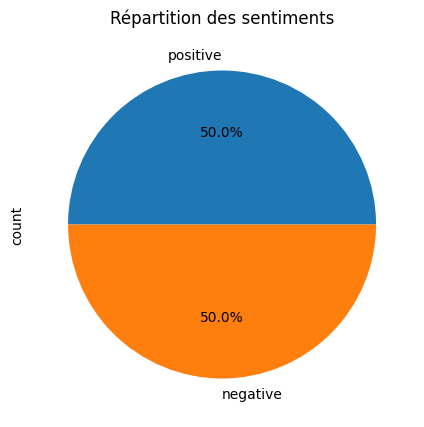

In [6]:
df['sentiment'].value_counts().plot.pie(figsize=(5,5), autopct='%1.1f%%')
plt.title('Répartition des sentiments')
plt.show()

Dataset parfaitement équilibré.

## Encodage de label

In [7]:
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

## Les features

In [8]:
df['review']

,review
0,One of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...
2,I thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is..."
...,...
49995,I thought this movie did a down right good job...
49996,"Bad plot, bad dialogue, bad acting, idiotic di..."
49997,I am a Catholic taught in parochial elementary...
49998,I'm going to have to disagree with the previou...


In [9]:
df['review'][0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

In [10]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [11]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [12]:
import re

In [13]:
def text_clean(text):
    if pd.isna(text):
        return ''
    # Convertir en chaîne, en minuscules et retirer les espaces aux extrémités
    text = str(text).lower().strip()
    # Supprimer les URLs
    text = re.sub(r'http\S+', '', text)
    # Supprimer les balises HTML (<br />, etc.)
    text = re.sub(r'<.*?>', '', text)
    # Supprimer les ponctuations
    text = re.sub(r'[^\w\s]', '', text)
    # Supprimer les chiffres
    text = re.sub(r'\d+', '', text)
    # Supprimer les espaces multiples en trop
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [14]:
text_clean(df['review'][0])

'one of the other reviewers has mentioned that after watching just oz episode youll be hooked they are right as this is exactly what happened with methe first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the wordit is called oz as that is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda em city is home to manyaryans muslims gangstas latinos christians italians irish and moreso scuffles death stares dodgy dealings and shady agreements are never far awayi would say the main appeal of the show is due to the fact that it goes where other shows wouldnt dare forget pretty pictures

In [15]:
# definir stop words
stop_words_set = set(stopwords.words('english')) - {'not'}
# defini stemmer
porter = PorterStemmer()

# 3. La fonction de nettoyage avancée corrigée
def advanced_clean(text):
    # tokenizer la phrase
    words = word_tokenize(text)

    # Filtrer, appliquer le Stemming et retirer les mots trop courts (< 3 lettres)
    filtered_words = [porter.stem(word) for word in words if word not in stop_words_set and len(word) > 2]

    # Reconstituer la chaîne de texte
    return ' '.join(filtered_words)

In [16]:
advanced_clean(text_clean(df['review'][0]))

'one review mention watch episod youll hook right exactli happen meth first thing struck brutal unflinch scene violenc set right word trust not show faint heart timid show pull punch regard drug sex violenc hardcor classic use wordit call nicknam given oswald maximum secur state penitentari focus mainli emerald citi experiment section prison cell glass front face inward privaci not high agenda citi home manyaryan muslim gangsta latino christian italian irish moreso scuffl death stare dodgi deal shadi agreement never far awayi would say main appeal show due fact goe show wouldnt dare forget pretti pictur paint mainstream audienc forget charm forget romanceoz doesnt mess around first episod ever saw struck nasti surreal couldnt say readi watch develop tast got accustom high level graphic violenc not violenc injustic crook guard wholl sold nickel inmat wholl kill order get away well manner middl class inmat turn prison bitch due lack street skill prison experi watch may becom comfort unco

In [17]:
def preprocess_dataframe(df):
  # clean text
  df['review'] = df['review'].apply(text_clean)
  # advanced clean
  df['review'] = df['review'].apply(advanced_clean)
  return df

In [18]:
df = preprocess_dataframe(df)

In [19]:
df.head()

,review,sentiment
0,one review mention watch episod youll hook rig...,1
1,wonder littl product film techniqu unassum old...,1
2,thought wonder way spend time hot summer weeke...,1
3,basic there famili littl boy jake think there ...,0
4,petter mattei love time money visual stun film...,1


# **2. La Vectorisation (TF-IDF ou Bag of Words)**

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

In [21]:
y = df['sentiment']
X = df['review']

In [22]:
# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [23]:
# TfidfVectorizer
vectorizer = TfidfVectorizer(
    max_features=8000,        # Limite le dictionnaire aux 8000 mots/phrases clés
    min_df=3,                 # Le mot doit apparaître au moins 3 fois
    max_df=0.8,               # Si un mot est présent dans plus de 80% des textes, on le vire
    ngram_range=(1, 3)        # Capture les mots seuls, les paires, et les triplets (ex: "not worth watch")
)

# transformation
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# **Entraînement et Comparaison des Modèles**

In [24]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC,LinearSVC
import time


In [25]:

# Initialisation des modèles avec la version rapide du SVM
modeles = {
    "Régression Logistique": LogisticRegression(max_iter=1000, random_state=42),
    "Naïve Bayes (Multinomial)": MultinomialNB(),
    "SVM Linéaire (Ultra-Fast)": LinearSVC(random_state=42, max_iter=2000)
}

# Boucle d'entraînement et d'évaluation
resultats = {}

for nom, modele in modeles.items():
    print(f"⏳ Entraînement de {nom}...")
    temps_debut = time.time()

    # Entraînement
    modele.fit(X_train_tfidf, y_train)

    # Prédiction
    y_pred = modele.predict(X_test_tfidf)

    # Calcul du score
    score = accuracy_score(y_test, y_pred)
    temps_execution = time.time() - temps_debut

    resultats[nom] = {'score': score, 'modele': modele}
    print(f"✨ {nom} terminé en {temps_execution:.2f}s | Précision (Accuracy) : {score*100:.2f}%")

print("\n CLASSEMENT DES MODÈLES ")
for nom, res in sorted(resultats.items(), key=lambda x: x[1]['score'], reverse=True):
    print(f"🥇 {nom} : {res['score']*100:.2f}% de bonnes réponses")

⏳ Entraînement de Régression Logistique...
✨ Régression Logistique terminé en 0.67s | Précision (Accuracy) : 89.27%
⏳ Entraînement de Naïve Bayes (Multinomial)...
✨ Naïve Bayes (Multinomial) terminé en 0.05s | Précision (Accuracy) : 86.48%
⏳ Entraînement de SVM Linéaire (Ultra-Fast)...
✨ SVM Linéaire (Ultra-Fast) terminé en 2.10s | Précision (Accuracy) : 88.71%

 CLASSEMENT DES MODÈLES 
🥇 Régression Logistique : 89.27% de bonnes réponses
🥇 SVM Linéaire (Ultra-Fast) : 88.71% de bonnes réponses
🥇 Naïve Bayes (Multinomial) : 86.48% de bonnes réponses


#**Optimisation du Meilleur Modèle (GridSearchCV)**

In [26]:
print("Recherche des meilleurs hyperparamètres pour la Régression Logistique...")

# Définition de la grille de paramètres (C contrôle la force de la régularisation)
param_grid = {
    'C': [0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}

# Configuration du GridSearch
grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    cv=5,          # Validation croisée en 5 étapes
    scoring='accuracy',
    n_jobs=-1      # Utilise tous les processeurs de Colab pour aller plus vite
)

# Exécution de la recherche
grid.fit(X_train_tfidf, y_train)

print(f"Meilleur score trouvé en validation croisée : {grid.best_score_*100:.2f}%")
print(f"Meilleurs paramètres : {grid.best_params_}")

# Sauvegarde du modèle final optimisé
best_model = grid.best_estimator_

Recherche des meilleurs hyperparamètres pour la Régression Logistique...
Meilleur score trouvé en validation croisée : 88.98%
Meilleurs paramètres : {'C': 1, 'solver': 'lbfgs'}


# **ÉVALUATION ET MATRICE DE CONFUSION**

 RAPPORT DE CLASSIFICATION FINAL 
              precision    recall  f1-score   support

 Négatif (0)       0.90      0.89      0.89      5000
 Positif (1)       0.89      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



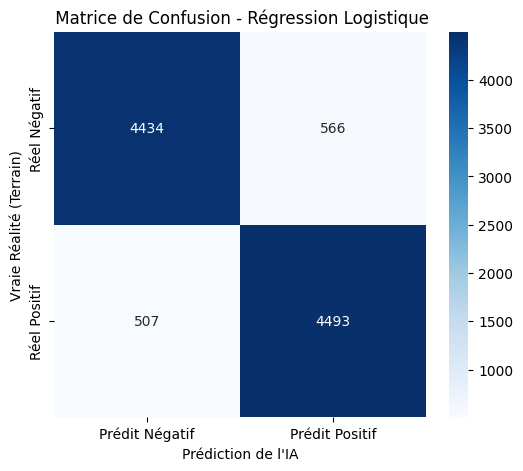

In [27]:
# Récupération du meilleur modèle du classement
meilleur_modele = resultats["Régression Logistique"]['modele']
y_pred_final = meilleur_modele.predict(X_test_tfidf)

# Affichage du rapport de classification complet
print(" RAPPORT DE CLASSIFICATION FINAL ")
print(classification_report(y_test, y_pred_final, target_names=['Négatif (0)', 'Positif (1)']))

#  Calcul et affichage graphique de la matrice de confusion
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prédit Négatif', 'Prédit Positif'],
            yticklabels=['Réel Négatif', 'Réel Positif'])
plt.title(" Matrice de Confusion - Régression Logistique")
plt.ylabel('Vraie Réalité (Terrain)')
plt.xlabel('Prédiction de l\'IA')
plt.show()

In [33]:

def predire_sentiment(phrase_brute):
    #  On applique le nettoyage textuel complet
    phrase_propre = advanced_clean(text_clean(phrase_brute))

    # Vectorisation (on utilise .transform, SURTOUT PAS .fit_transform)
    phrase_tfidf = vectorizer.transform([phrase_propre])

    # Prédiction du label et des probabilités
    prediction = meilleur_modele.predict(phrase_tfidf)[0]
    probabilites = meilleur_modele.predict_proba(phrase_tfidf)[0]

    sentiment = "POSITIF  " if prediction == 1 else "NÉGATIF 😡"
    certitude = probabilites[prediction] * 100

    print(f"Phrase : '{phrase_brute}'")
    print(f"Verdict de l'IA : {sentiment} | Certitude : {certitude:.2f}%\n")


print(" SIMULATION EN DIRECT ---")
predire_sentiment("This movie was an absolute masterpiece! The acting was incredible.")
predire_sentiment("I fell asleep after 20 minutes. Total waste of time and money, do not watch.")
predire_sentiment("The visual effects were stunning, but the plot was honestly not very good.")
predire_sentiment("It's good movie")

 SIMULATION EN DIRECT ---
Phrase : 'This movie was an absolute masterpiece! The acting was incredible.'
Verdict de l'IA : POSITIF   | Certitude : 75.42%

Phrase : 'I fell asleep after 20 minutes. Total waste of time and money, do not watch.'
Verdict de l'IA : NÉGATIF 😡 | Certitude : 99.75%

Phrase : 'The visual effects were stunning, but the plot was honestly not very good.'
Verdict de l'IA : NÉGATIF 😡 | Certitude : 78.19%

Phrase : 'It's good movie'
Verdict de l'IA : POSITIF   | Certitude : 82.83%

